# Train and Predict Drones

### Abstract

...


### Introduction

...


### Dataset



# 🏁 1. Initialization

pip install `ultralytics` and [dependencies](https://github.com/ultralytics/ultralytics/blob/main/pyproject.toml) and check software and hardware.

[![PyPI - Version](https://img.shields.io/pypi/v/ultralytics?logo=pypi&logoColor=white)](https://pypi.org/project/ultralytics/) [![PyPI - Python Version](https://img.shields.io/pypi/pyversions/ultralytics?logo=python&logoColor=gold)](https://pypi.org/project/ultralytics/)

### 1.0 Installing dependencies

In [ ]:
!pip install ultralytics markdown rich wrapt pandas mlflow huggingface_hub opencv-python wandb datasets -q

### 1.1 Importing Libraries

In [6]:
from datasets import load_dataset, Image, concatenate_datasets, DatasetDict
from IPython.display import display, Image as IPyImage
from sklearn.model_selection import KFold
from ultralytics import YOLO, settings
from typing import Iterable, Union
import matplotlib.pyplot as plt
from collections import Counter
from dotenv import load_dotenv
from datetime import datetime
from pathlib import Path
from PIL import Image

from tqdm import tqdm
import pandas as pd
import ultralytics
import numpy as np
import datetime
import random
import shutil
import wandb
import uuid
import yaml
import math
import re
import os

ultralytics.checks()

Ultralytics 8.4.7 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA A10, 22588MiB)
Setup complete ✅ (96 CPUs, 377.7 GB RAM, 4764.3/5037.1 GB disk)


### 1.2 Global Definitions

In [7]:
DATASET_ROOT_DIR = Path('./datasets/main')
DATASET_ALL_DIR = DATASET_ROOT_DIR / 'train_validation_test'
TRAINING_DATASET_DIRECTORY = DATASET_ROOT_DIR / 'train'
VALIDATION_DATASET_DIRECTORY = DATASET_ROOT_DIR / 'valid/'
TEST_DATASET_DIRECTORY = DATASET_ROOT_DIR / 'test/'
MODELS_DIRECTORY = Path('./models/')
load_dotenv()

False

### 1.3 Global Settings

In [8]:
# YOLO settings
settings.update({"wandb": True})

# Initialize Weights & Biases environment
wandb.login(key=os.getenv("WANDB_TOKEN"))

# login("TOKEN") # Keep commented if token loaded from .env file

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jovyan/.netrc.
wandb: Currently logged in as: cqsv20ajs (hibou) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### 1.4 Global Structure

In [9]:
dataset_structure = {
    "root": Path(""),
    "name": "",
    "classes": [],
    "train": {
        "images": [],
        "labels": [],
    },
    "valid": {
        "images": [],
        "labels": [],
    },
    "test": {
        "images": [],
        "labels": [],
    },
}


### 1.5 Global Function Definitions

In [10]:
from itertools import chain


def list_files(
        directory: Union[str, Path],
        extensions: Iterable[str],
        include_root_directory: bool = False,
        recursive: bool = False,
) -> list[Path]:
    directory = Path(directory)
    extensions = tuple(extensions)

    matched_files = []

    if recursive:
        iterator = directory.rglob("*")
    else:
        iterator = directory.iterdir()

    for p in iterator:
        if p.is_file() and p.suffix in extensions:
            matched_files.append(
                p if include_root_directory else p.name
            )

    return matched_files


def numeric_key(name):
    """Extract the first number from a filename for sorting."""
    nums = re.findall(r'\d+', name)
    return int(nums[0]) if nums else float('inf')


def sort_files_by_number(files_to_sort: list):
    """
    Sort a list of filenames by the first number found in each name.

    Args:
        files_to_sort (list): List of filenames (strings)

    Returns:
        list: Sorted list of filenames
    """
    return sorted(files_to_sort, key=lambda i: int(i.stem))


def update_dataset_structure():
    dataset_structure["root"] = Path(DATASET_ROOT_DIR)
    dataset_structure["name"] = DATASET_ROOT_DIR.name

    dataset_structure["train"]["images"] = sort_files_by_number(
        list_files(TRAINING_DATASET_DIRECTORY, [".jpg", ".jpeg", ".JPG", ".JPEG"], True))
    dataset_structure["train"]["labels"] = sort_files_by_number(list_files(TRAINING_DATASET_DIRECTORY, [".txt"], True))

    dataset_structure["valid"]["images"] = sort_files_by_number(
        list_files(VALIDATION_DATASET_DIRECTORY, [".jpg", ".jpeg", ".JPG", ".JPEG"], True))
    dataset_structure["valid"]["labels"] = sort_files_by_number(
        list_files(VALIDATION_DATASET_DIRECTORY, [".txt"], True))

    dataset_structure["test"]["images"] = sort_files_by_number(
        list_files(VALIDATION_DATASET_DIRECTORY, [".jpg", ".jpeg", ".JPG", ".JPEG"], True))
    dataset_structure["test"]["labels"] = sort_files_by_number(list_files(VALIDATION_DATASET_DIRECTORY, [".txt"], True))

    dataset_structure["classes"] = ["drone", "other"]


def delete_files_in_dataset(files_to_delete: list):
    try:
        confirm = input("Files are going to be deleted. Type 'yes' to continue: ").strip().lower()
        if confirm != 'yes':
            print("Deletion aborted by user.")
            return

        for file in files_to_delete:
            if os.path.isfile(file):
                os.remove(file)
                print(f"Deleted: {file}")
            else:
                print(f"Warning: File does not exist: {file}")

    except KeyboardInterrupt:
        print("\nDeletion aborted by user (KeyboardInterrupt).")
    finally:
        try:
            update_dataset_structure()
        except NameError:
            pass


def backup_dataset():
    dataset_path = dataset_structure.get("path", "")
    backup_dir = os.path.join(dataset_path, "backup")
    os.makedirs(backup_dir, exist_ok=True)

    now = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    target_name = f"{dataset_structure["name"]}-{now}"
    target_path = os.path.join(backup_dir, target_name)

    def ignore_backup(_, names):
        return {"backup"} if "backup" in names else set()

    shutil.copytree(dataset_path, target_path, ignore=ignore_backup)
    print(f"Backup created at: {target_path}")
    return str(target_path)


def interpret_map(map_value: float) -> str:
    """
    Interpret mAP value according to standard object detection heuristics.
    """
    if map_value < 0.10:
        return "Model is effectively failing"
    elif map_value < 0.30:
        return "Very weak performance"
    elif map_value < 0.50:
        return "Usable baseline"
    elif map_value < 0.70:
        return "Good performance"
    else:
        return "Strong performance"

# 📂 2. Dataset

### 2.0 Acquire Dataset

Download dataset from hugging face.

In [ ]:
dataset = load_dataset("Hibou-Foundation/computer-vision")

### 2.1 Split dataset

Split the dataset into train, validation, test.

In [ ]:
base_split = "train_validation_test"
label_column = "class_id"

train_ratio = [0.1, 0.1]  # [class 0, class 1]
valid_ratio = [0.1, 0.1]
test_ratio = [0.8, 0.8]

seed = 42

for i in range(len(train_ratio)):
    assert train_ratio[i] + valid_ratio[i] + test_ratio[i] == 1.0

train_parts = []
valid_parts = []
test_parts = []

num_classes = len(train_ratio)

for cls in range(num_classes):
    cls_ds = dataset[base_split].filter(
        lambda x: x[label_column] == cls
    )

    cls_ds = cls_ds.shuffle(seed=seed)

    n = len(cls_ds)
    n_train = int(n * train_ratio[cls])
    n_valid = int(n * valid_ratio[cls])

    train_parts.append(cls_ds.select(range(0, n_train)))
    valid_parts.append(cls_ds.select(range(n_train, n_train + n_valid)))
    test_parts.append(cls_ds.select(range(n_train + n_valid, n)))

train_ds = concatenate_datasets(train_parts).shuffle(seed=seed)
valid_ds = concatenate_datasets(valid_parts).shuffle(seed=seed)
test_ds = concatenate_datasets(test_parts).shuffle(seed=seed)

dataset = DatasetDict({
    "train": train_ds,
    "validation": valid_ds,
    "test": test_ds,
})
dataset

### 2.2 Convert to file images

In [ ]:
# Create folders
for split in ["train", "valid", "test"]:
    os.makedirs(f"{DATASET_ROOT_DIR}/{split}", exist_ok=True)


def export_to_yolo(ds, split_name):
    for idx, sample in enumerate(ds):
        image = sample["image"]  # already a PIL.Image
        label = sample["raw_label"]  # already YOLO format [[class, cx, cy, w, h], ...]
        img_name = sample["name"]
        txt_name = img_name.split(".")[0] + ".txt"

        # Save image
        img_path = f"{DATASET_ROOT_DIR}/{split_name}/{img_name}"
        image.save(img_path, quality=95)

        # Save labels
        lbl_path = f"{DATASET_ROOT_DIR}/{split_name}/{txt_name}"
        with open(lbl_path, "w") as f:
            f.write(label)


# Run export
split_mapping = {"train": "train", "validation": "valid", "test": "test"}
for hf_split, folder_name in split_mapping.items():
    export_to_yolo(dataset[hf_split], folder_name)
update_dataset_structure()

# 📚️ 3. Models Settings

### 3.1 Model selection

In [18]:
selected_size = "nano"
selected_version = "11"

YOLO_MODEL_SIZE = {
    "nano": "n",
    "small": "s",
    "medium": "m",
    "large": "l",
    "xlarge": "x",
}
run_session_id = str(uuid.uuid4()).split("-")[0]  # For wandb
model_name = f"yolo{selected_version}{YOLO_MODEL_SIZE[selected_size]}.pt"
model_path = MODELS_DIRECTORY / model_name
model = YOLO(model_path, task="detect")

### 3.2 Training Configuration
Define hyperparameters (epochs, batch size, image size)

In [12]:
train_config = {
    'epochs': 1,
    'imgsz': 640,
    'batch': 16,
    'lr0': 0.001,
    'optimizer': 'AdamW',
    'project': 'computer-vision',
    'device': [0]
}
train_config

{'epochs': 1,
 'imgsz': 640,
 'batch': 16,
 'lr0': 0.001,
 'optimizer': 'AdamW',
 'project': 'computer-vision',
 'device': [0]}

**Parameter breakdown:**

- **train**: Executes the YOLOv11x training pipeline.
- **model**=yolov11x.pt: Uses pre-trained YOLOv11x weights as initialization.
- **data**=/content/data.yaml: Specifies the dataset configuration file.
- **imgsz**=640: Sets input resolution to enhance small-object detection.
- **lr0**=0.001: Sets the learning rate for each training step.
- **epochs**=32: Defines the number of training cycles over the dataset.
- **batch**=16: Sets the batch size for each training step.
- **device**=0: Allocates GPU device 0 for training.
- **optimizer**=AdamW: As default, AdamW optimization algorithm utilized.

# 🔍️ 4. Hyperparameter Tuning

- [Official documentation](https://docs.ultralytics.com/guides/hyperparameter-tuning/)

## 4.1 Genetic Algorithm

In [ ]:
# Define search space
search_space = {
    "lr0": (1e-5, 1e-1),
    "degrees": (0.0, 45.0),
}
resume_tuning = False

In [ ]:
data_yaml = dict(
    train=os.path.join('../../', TRAINING_DATASET_DIRECTORY),
    val=os.path.join('../../', VALIDATION_DATASET_DIRECTORY),
    nc=2,
    names=['drone', 'other']
)

data_config_path = os.path.join(DATASET_ROOT_DIR, 'data.yaml')

with open(data_config_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=True)

%cat "$data_config_path"

In [ ]:
model.tune(
    data="coco8.yaml",
    epochs=30,
    iterations=300,
    optimizer="AdamW",
    space=search_space,
    plots=False,
    save=False,
    val=False,
    resume=resume_tuning,
)

## 4.2 K-Fold Cross Validation

#### 4.2.1 Load labels and classes

In [ ]:
update_dataset_structure()

train_path = TRAINING_DATASET_DIRECTORY
valid_path = VALIDATION_DATASET_DIRECTORY
test_path = TEST_DATASET_DIRECTORY

labels = list(chain(dataset_structure["train"]["labels"], dataset_structure["valid"]["labels"]))

cls_idx = list(range(len(dataset_structure["classes"])))
classes = list(dataset_structure["classes"])

#### 4.2.2 Init empty pandas DataFram

In [ ]:
index = [label.stem for label in labels]  # uses base filename as ID (no extension)
labels_df = pd.DataFrame([], columns=cls_idx, index=index)

#### 4.2.3 Count the instances of each class-label present in the annotation files.

In [ ]:
for label in labels:
    lbl_counter = Counter()

    with open(label) as lf:
        lines = lf.readlines()

    for line in lines:
        # classes for YOLO label use integer at the first position of each line
        lbl_counter[int(line.split(" ", 1)[0])] += 1

    labels_df.loc[label.stem] = lbl_counter

labels_df = labels_df.fillna(0.0).infer_objects(copy=False)  # replace `nan` values with `0.0`
labels_df

#### 4.2.4 Configure K-Fold Dataset Split

In [ ]:
random.seed(0)  # for reproducibility
k_split = 5
kf = KFold(n_splits=k_split, shuffle=True, random_state=20)  # setting random_state for repeatable results

k_folds = list(kf.split(labels_df))

#### 4.2.5 Do something

In [ ]:
folds = [f"split_{n}" for n in range(1, k_split + 1)]
folds_df = pd.DataFrame(index=index, columns=folds)

for i, (train, val) in enumerate(k_folds, start=1):
    col = f"split_{i}"

    folds_df.loc[labels_df.iloc[train].index, col] = "train"
    folds_df.loc[labels_df.iloc[val].index, col] = "val"


#### 4.2.6 Do something

In [ ]:
fold_lbl_distrb = pd.DataFrame(index=folds, columns=cls_idx)

for n, (train_indices, val_indices) in enumerate(k_folds, start=1):
    train_totals = labels_df.iloc[train_indices].sum()
    val_totals = labels_df.iloc[val_indices].sum()

    # To avoid division by zero, we add a small value (1E-7) to the denominator
    ratio = val_totals / (train_totals + 1e-7)
    fold_lbl_distrb.loc[f"split_{n}"] = ratio

#### 4.2.7 Create the directories

In [ ]:
# Initialize an empty list to store image file paths
images = list(chain(dataset_structure["train"]["images"], dataset_structure["valid"]["images"]))

# Create the necessary directories and dataset YAML files
save_path = Path(DATASET_ROOT_DIR / f"{datetime.date.today().isoformat()}_{k_split}-Fold_Cross-val")
save_path.mkdir(parents=True, exist_ok=True)
ds_yamls = []

for split in folds_df.columns:
    # Create directories
    split_dir = save_path / split
    split_dir.mkdir(parents=True, exist_ok=True)
    (split_dir / "train").mkdir(parents=True, exist_ok=True)
    (split_dir / "val").mkdir(parents=True, exist_ok=True)

    # Create dataset YAML files
    dataset_yaml = split_dir / f"{split}_dataset.yaml"
    ds_yamls.append(dataset_yaml)

    with open(dataset_yaml, "w") as ds_y:
        yaml.safe_dump(
            {
                "path": split_dir.as_posix(),
                "train": "train",
                "val": "val",
                "names": classes,
            },
            ds_y,
        )

#### 4.2.8 Copy the files

In [ ]:
for image, label in tqdm(zip(images, labels), total=len(images), desc="Copying files"):
    for split, k_split in folds_df.loc[image.stem].items():
        # Destination directory
        img_to_path = save_path / str(split) / k_split
        lbl_to_path = save_path / str(split) / k_split

        # Copy image and label files to a new directory (SamefileError if a file already exists)
        shutil.copy(image, img_to_path / image.name)
        shutil.copy(label, lbl_to_path / label.name)

In [ ]:
results = {}

for k, dataset_yaml in enumerate(ds_yamls):
    fold_run_name = f"{selected_version}-{selected_size}-{run_session_id}-fold_{k + 1}"

    model = YOLO(model_path, task="detect")
    results[k] = model.train(data=dataset_yaml, name=fold_run_name, **train_config)

In [ ]:
cv_metrics = {}

for k, dataset_yaml in enumerate(ds_yamls):
    model_path = Path(results[k].save_dir) / "weights/best.pt"
    fold_run_name = f"{selected_version}-{selected_size}-{run_session_id}-val-fold_{k + 1}"

    print(fold_run_name)

    validation_model = YOLO(model_path)
    metrics = validation_model.val(data=dataset_yaml, name=fold_run_name, **train_config, plots=True)

    cv_metrics[k] = {
        "mAP50": metrics.box.map50,
        "mAP75": metrics.box.map75,
        "mAP50-95": metrics.box.map,
        "per_class": metrics.box.maps,
    }

In [ ]:
map50 = np.mean([m["mAP50"] for m in cv_metrics.values()])
map75 = np.mean([m["mAP75"] for m in cv_metrics.values()])
map5095 = np.mean([m["mAP50-95"] for m in cv_metrics.values()])

map50_std = np.std([m["mAP50"] for m in cv_metrics.values()])
map75_std = np.std([m["mAP75"] for m in cv_metrics.values()])
map5095_std = np.std([m["mAP50-95"] for m in cv_metrics.values()])

print(f"mAP50:\t\t{map50:.4f} ± {map50_std:.4f} → " f"{interpret_map(float(map50))}")
print(f"mAP75:\t\t{map75:.4f} ± {map75_std:.4f} → "f"{interpret_map(float(map75))}")
print(f"mAP50-95:\t{map5095:.4f} ± {map5095_std:.4f} → " f"{interpret_map(float(map5095))}")

# ⚙️ 5. Training

Purpose: Handle model setup and training configuration.

### 5.1 Save dataset configuration

In [13]:
data_yaml = dict(
    train=os.path.join('../../', TRAINING_DATASET_DIRECTORY),
    val=os.path.join('../../', VALIDATION_DATASET_DIRECTORY),
    nc=2,
    names=['drone', 'other']
)

data_config_path = os.path.join(DATASET_ROOT_DIR, 'data.yaml')

with open(data_config_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=True)
%cat "$data_config_path"

{names: [drone, other], nc: 2, train: ../../datasets/main/train, val: ../../datasets/main/valid}


### 5.2 Run Training

In [30]:
run_name = f"{selected_version}-{selected_size}-{run_session_id}"
results = model.train(**train_config,
                      data=data_config_path,
                      name=run_name)

### 5.3 Trainin results

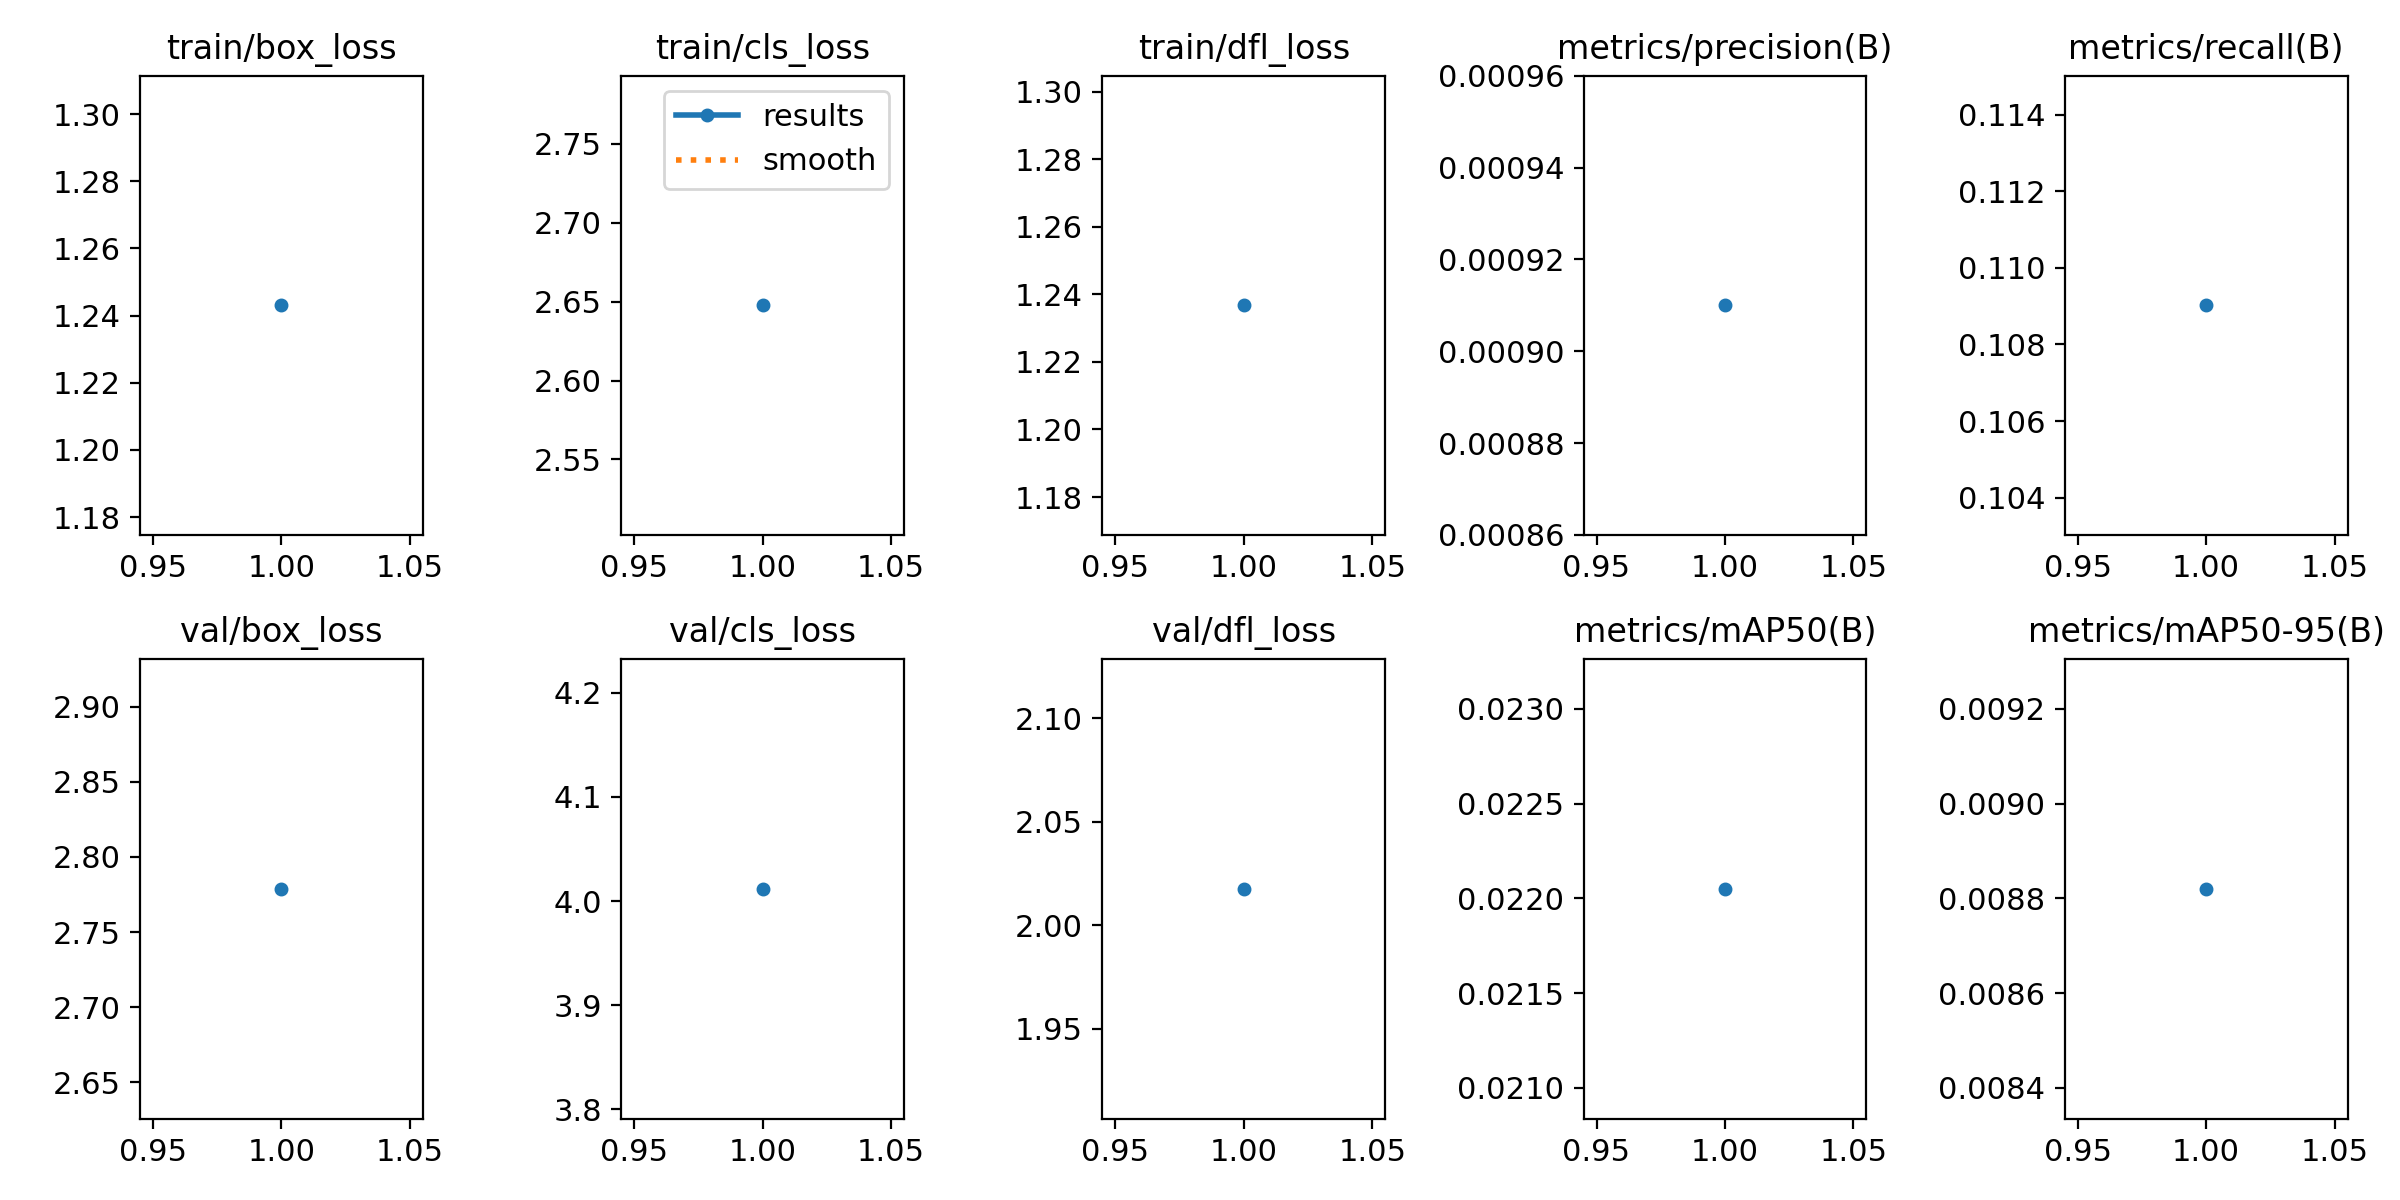

In [25]:
result_dir = Path(results.save_dir)
display(IPyImage(filename=str(result_dir / "results.png")))

In [ ]:
# %matplotlib inline
# results_paths = []
#
# for root, _, files in os.walk(result_dir):
#     for f in files:
#         if f.lower().endswith((".jpg")):
#             results_paths.append(os.path.join(root, f))
# results_paths = sorted(results_paths)
#
# for path in results_paths:
#     image = np.array(Image.open(path))
#     plt.figure(figsize=(20, 10))
#     plt.imshow(image)
#     plt.axis("off")
#     plt.show()

# ✅️ 6. Validation

###  6.1 Evaluate Model

In [23]:
metrics = model.val()

Ultralytics 8.4.7 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA A10, 22588MiB)


[W123 18:01:52.683826000 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.696349240 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.780612374 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.788235448 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.804172180 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.889237047 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.900193712 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.984224534 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.991295298 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:52.005167452 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:0

YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


[W123 18:01:54.193324484 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:54.201250220 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:54.296227928 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:54.315207120 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:55.380667832 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W123 18:01:55.387087253 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1129.1±436.4 MB/s, size: 626.3 KB)
val: Scanning /home/jovyan/datasets/main/valid.cache... 460 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 460/460 91.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.9it/s 5.9s0.2s
                   all        460        560   0.000939       0.11     0.0219    0.00884
                 drone        432        532    0.00188       0.22     0.0439     0.0177
                 other         28         28          0          0          0          0
Speed: 1.3ms preprocess, 3.4ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /home/jovyan/runs/detect/val


In [ ]:
print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.map75)
print(metrics.box.maps)

# 7. Evaluation / Inference

Purpose: Evaluate results qualitatively and quantitatively.


### 7.0 Load model

In [26]:
best_path = result_dir / "weights/best.pt"
# best_path = os.path.join("./computer-vision/nano11", "weights/best.pt")
custom_model = YOLO(best_path)

### 7.1 Run Predictions (IMAGES)

In [40]:
predictions = custom_model.predict(
    TEST_DATASET_DIRECTORY,
    save=True,
    project=Path('computer-vision', run_name),
    conf=0.25
)
predictions_output_dir = predictions[0].save_dir


image 1/626 /home/jovyan/datasets/main/test/0.jpg: 384x640 (no detections), 8.8ms
image 2/626 /home/jovyan/datasets/main/test/1.jpg: 384x640 (no detections), 7.2ms
image 3/626 /home/jovyan/datasets/main/test/10.jpg: 384x640 (no detections), 7.0ms
image 4/626 /home/jovyan/datasets/main/test/1000.jpg: 384x640 (no detections), 7.2ms
image 5/626 /home/jovyan/datasets/main/test/1002.jpg: 384x640 (no detections), 6.8ms
image 6/626 /home/jovyan/datasets/main/test/1003.jpg: 384x640 (no detections), 6.6ms
image 7/626 /home/jovyan/datasets/main/test/1004.jpg: 384x640 (no detections), 6.8ms
image 8/626 /home/jovyan/datasets/main/test/1006.jpg: 384x640 (no detections), 6.8ms
image 9/626 /home/jovyan/datasets/main/test/1007.jpg: 384x640 (no detections), 6.8ms
image 10/626 /home/jovyan/datasets/main/test/1008.jpg: 384x640 (no detections), 6.5ms
image 11/626 /home/jovyan/datasets/main/test/101.jpg: 384x640 (no detections), 6.4ms
image 12/626 /home/jovyan/datasets/main/test/1010.jpg: 384x640 (no dete

### 7.2 Visualize Predictions

In [45]:
predictions_paths = []

for root, _, files in os.walk(predictions_output_dir):
    for f in files:
        if f.lower().endswith((".jpg", ".png", ".jpeg")):
            predictions_paths.append(os.path.join(root, f))

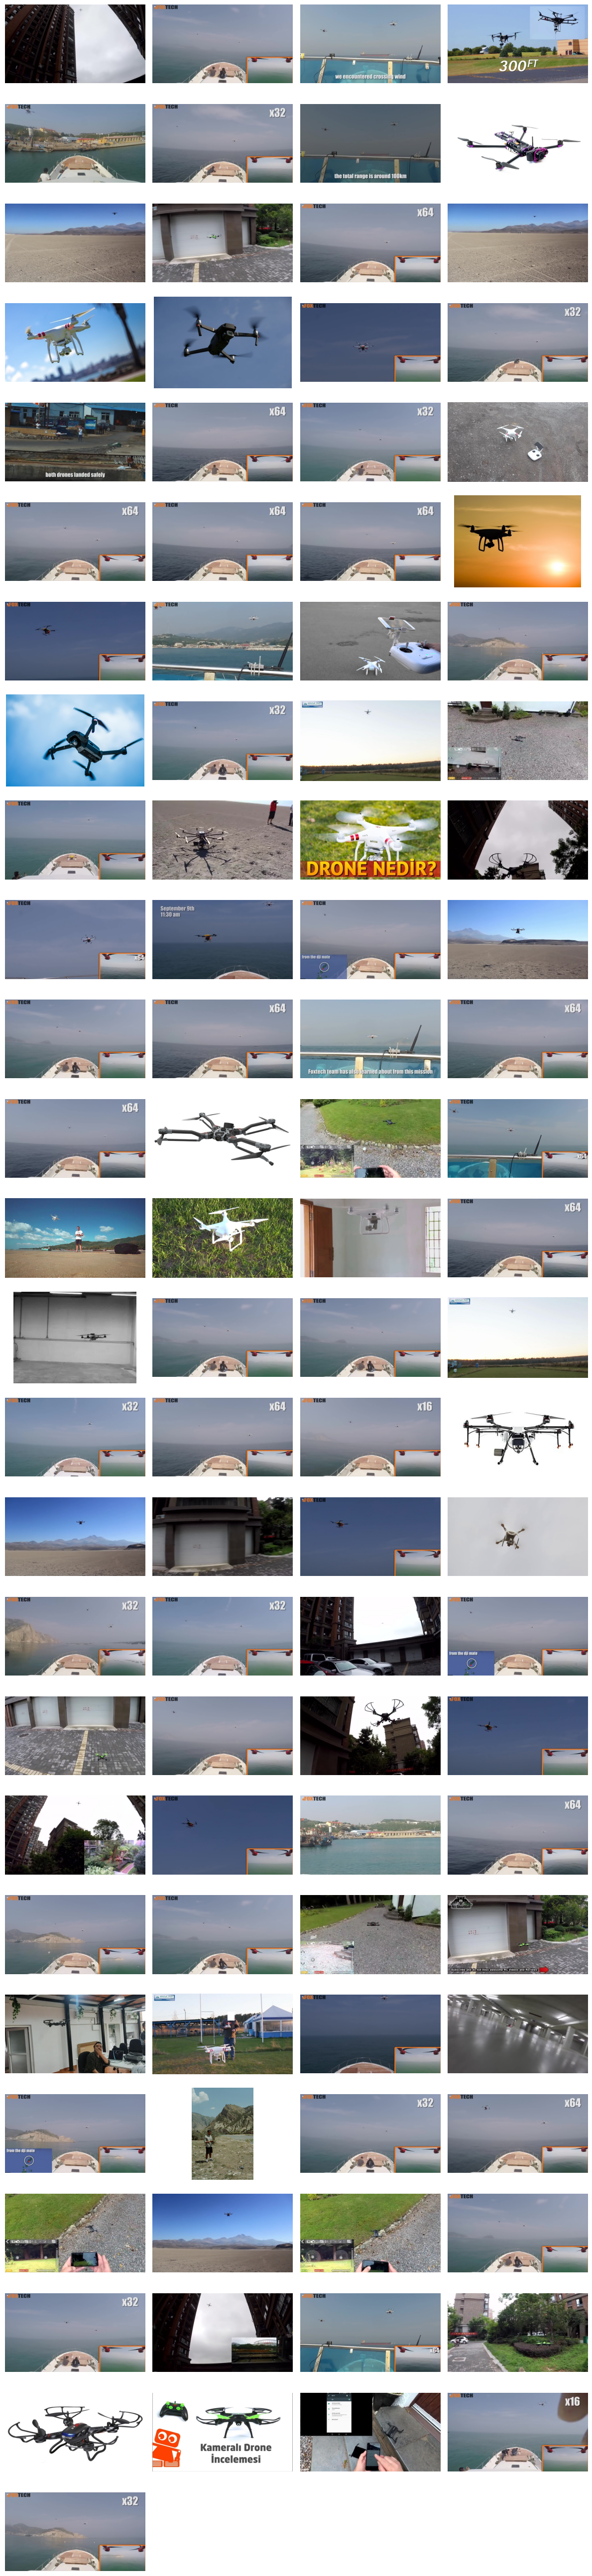

In [49]:
cols = 4
max_images_preview = 100
rows = math.ceil(len(predictions_paths) / cols)

plt.figure(figsize=(cols * 3, rows * 2))  # dynamic size
for i, path in enumerate(predictions_paths):
    if max_images_preview != -1 and max_images_preview < i:
        break
    img = Image.open(path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 7.3 Run Predictions (VIDEOS)

In [50]:
result = custom_model.track(
    source="https://www.youtube.com/watch?v=aZjRQfBWLEo",
    conf=0.3,
    iou=0.5,
    show=False,
    imgsz=640,
    save=True,
    project=Path('computer-vision', run_name),
    exist_ok=True
)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.7 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.0 MB/s  0:00:00

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


requirements: Ultralytics requirement ['pytubefix>=6.5.2'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/60.2 MB ? eta -:--:--
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/60.2 MB 110.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 32.5/60.2 MB 83.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━ 50.6/60.2 MB 84.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 MB 85.3 MB/s  0:00:00

   ━━━━━━━━━━━━━

# ⛴️ 8. Export & Deployment

### Supported Formats

- [Source](https://docs.ultralytics.com/modes/export/#arguments)

| Format                                             | `format` Argument |
|----------------------------------------------------|-------------------|
| [PyTorch](https://pytorch.org/)                    | -                 |
| [TorchScript](../integrations/torchscript.md)      | `torchscript`     |
| [ONNX](../integrations/onnx.md)                    | `onnx`            |
| [OpenVINO](../integrations/openvino.md)            | `openvino`        |
| [TensorRT](../integrations/tensorrt.md)            | `engine`          |
| [CoreML](../integrations/coreml.md)                | `coreml`          |
| [TF SavedModel](../integrations/tf-savedmodel.md)  | `saved_model`     |
| [TF GraphDef](../integrations/tf-graphdef.md)      | `pb`              |
| [TF Lite](../integrations/tflite.md)               | `tflite`          |
| [TF Edge TPU](../integrations/edge-tpu.md)         | `edgetpu`         |
| [TF.js](../integrations/tfjs.md)                   | `tfjs`            |
| [PaddlePaddle](../integrations/paddlepaddle.md)    | `paddle`          |
| [MNN](../integrations/mnn.md)                      | `mnn`             |
| [NCNN](../integrations/ncnn.md)                    | `ncnn`            |
| [IMX500](../integrations/sony-imx500.md){{ tip3 }} | `imx`             |
| [RKNN](../integrations/rockchip-rknn.md)           | `rknn`            |
| [ExecuTorch](../integrations/executorch.md)        | `executorch`      |
| [Axelera](../integrations/axelera.md)              | `axelera`         |

In [ ]:
model.export(format="onnx")